<a href="https://colab.research.google.com/github/Vaish2511/Predicting-Smart-Grid-Stability/blob/main/Predicting_Smart_Grid_Stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

from keras.models import Sequential
from keras.layers import Dense

from datetime import datetime

In [2]:
def assessment(f_data, f_y_feature, f_x_feature, f_index=-1):
      for f_row in f_data:
        if f_index >= 0:
            f_color = np.where(f_data[f_row].index == f_index,'r','g')
            f_hue = None
        else:
            f_color = 'b'
            f_hue = None

      f_fig, f_a = plt.subplots(1, 2, figsize=(16,4))
      f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')
      f_chart1.set_xlabel(f_x_feature,fontsize=10)

      if f_index >= 0:
        f_chart2 = plt.scatter(f_data[f_x_feature], f_data[f_y_feature], c=f_color, edgecolors='w')
        f_chart2 = plt.xlabel(f_x_feature, fontsize=10)
        f_chart2 = plt.ylabel(f_y_feature, fontsize=10)
      else:
        f_chart2 = sns.scatterplot(x=f_x_feature, y=f_y_feature, data=f_data, hue=f_hue, legend=False)
        f_chart2.set_xlabel(f_x_feature,fontsize=10)
        f_chart2.set_ylabel(f_y_feature,fontsize=10)

      plt.show()


def correlation_map(f_data, f_feature, f_number):
    f_most_correlated = f_data.corr().nlargest(f_number,f_feature)[f_feature].index
    f_correlation = f_data[f_most_correlated].corr()
    f_mask = np.zeros_like(f_correlation)
    f_mask[np.triu_indices_from(f_mask)] = True
    with sns.axes_style("white"):
        f_fig, f_ax = plt.subplots(figsize=(20, 10))
        sns.heatmap(f_correlation, mask=f_mask, vmin=-1, vmax=1, square=True,
                    center=0, annot=True, annot_kws={"size": 8}, cmap="PRGn")
    plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
sns.set()
start_time = datetime.now()

data = pd.read_csv("/content/drive/MyDrive/SG Mini Project/smart_grid_stability_augmented.csv")

map1 = {'unstable': 0, 'stable': 1}
data['stabf'] = data['stabf'].replace(map1)

data = data.sample(frac=1)

<ipython-input-4-85fe670175e8>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['stabf'] = data['stabf'].replace(map1)


In [5]:
data.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
49824,2.734176,2.251383,5.584945,1.073838,4.248879,-0.796186,-1.613219,-1.839473,0.267771,0.835480,0.173628,0.465763,-0.022454,1
27917,2.278950,5.731776,2.993927,2.045503,3.955003,-1.625561,-1.345974,-0.983468,0.424920,0.952179,0.600996,0.178514,0.018013,0
38078,3.718682,7.330911,3.667609,7.786623,4.668565,-1.843462,-1.168815,-1.656288,0.841145,0.489458,0.916222,0.957768,0.078909,0
22680,5.489023,7.805560,2.634709,7.170187,3.496537,-1.748310,-1.122814,-0.625413,0.751426,0.312917,0.135907,0.882692,0.053112,0
3659,5.806376,2.969342,2.873816,5.080283,4.455209,-1.407880,-1.707970,-1.339358,0.086858,0.237457,0.826670,0.104431,-0.039174,1


<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


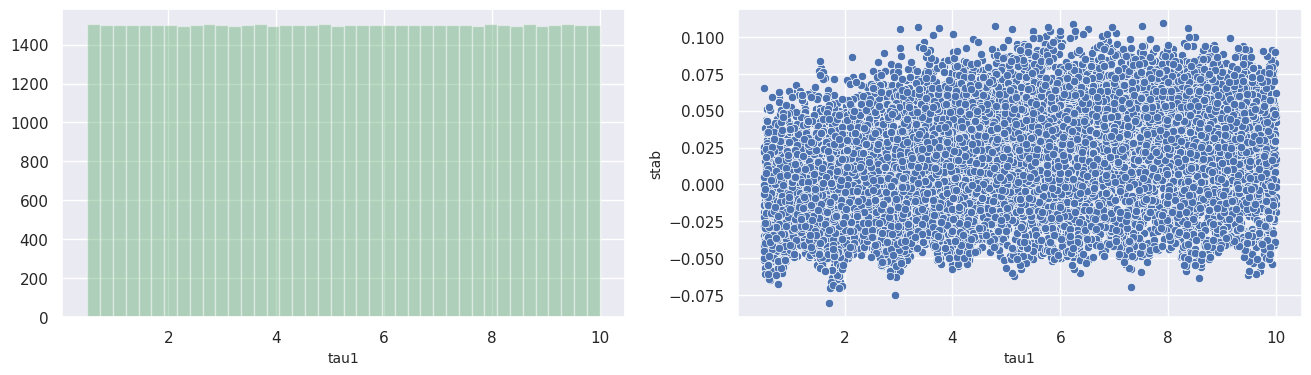

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


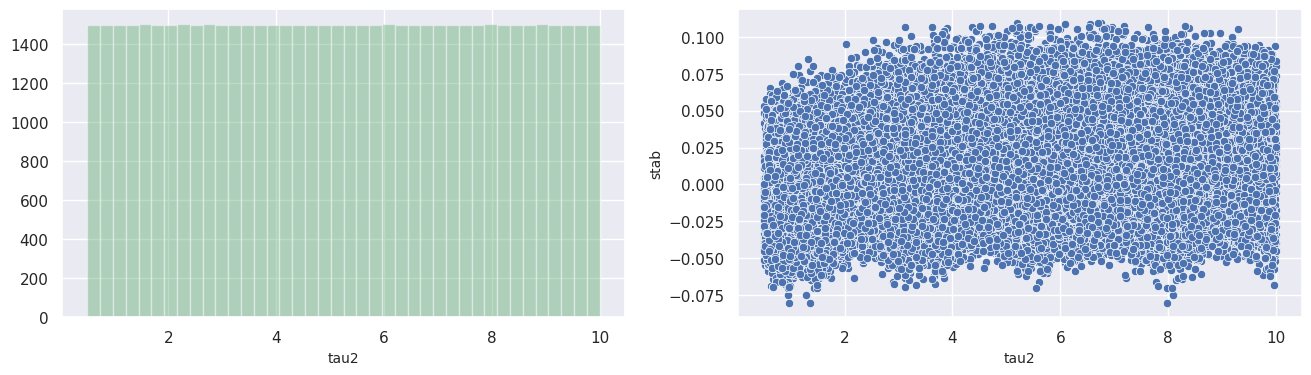

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


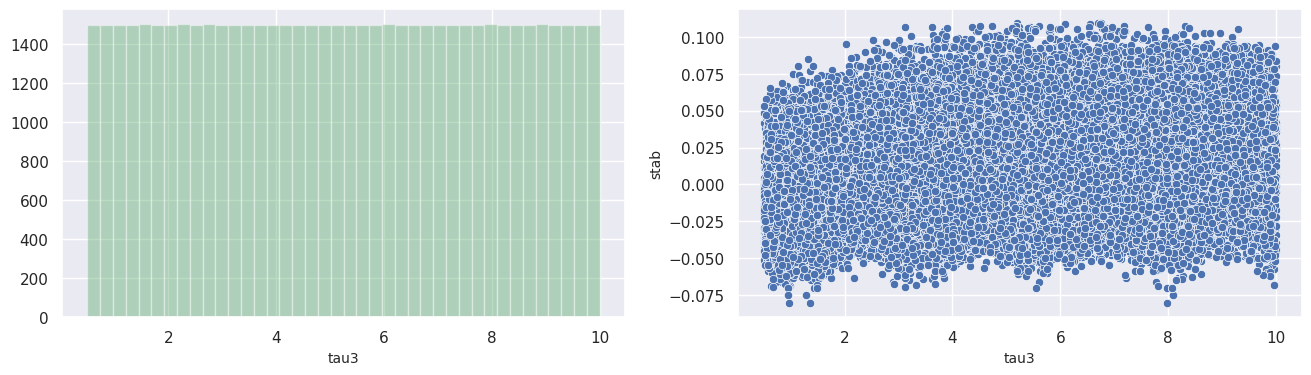

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


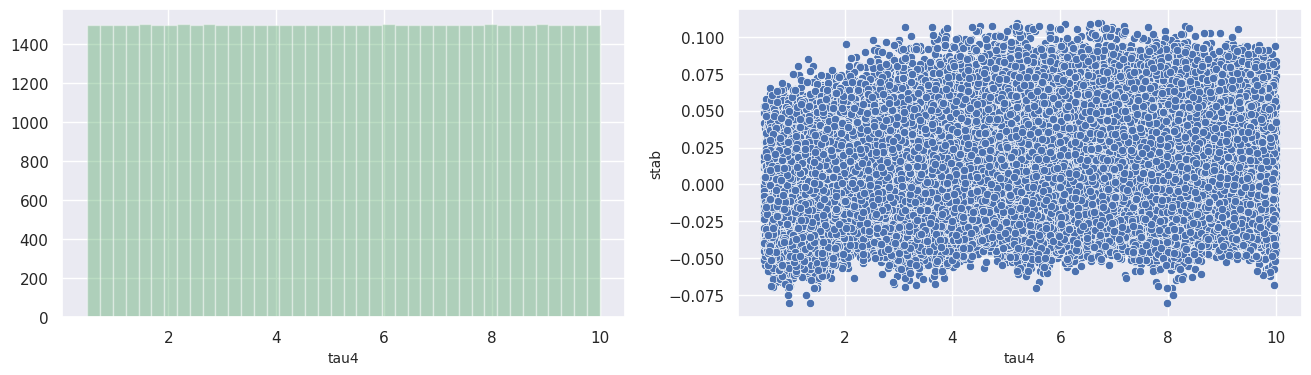

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


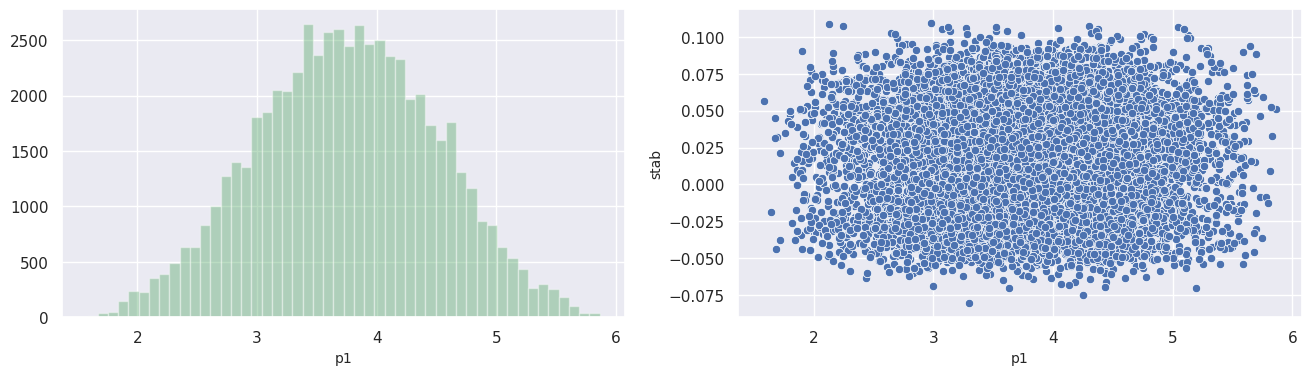

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


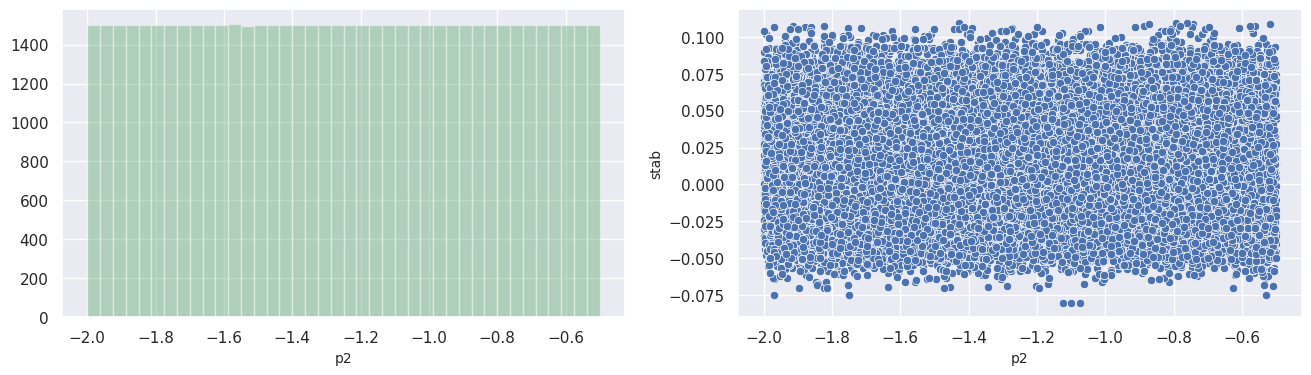

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


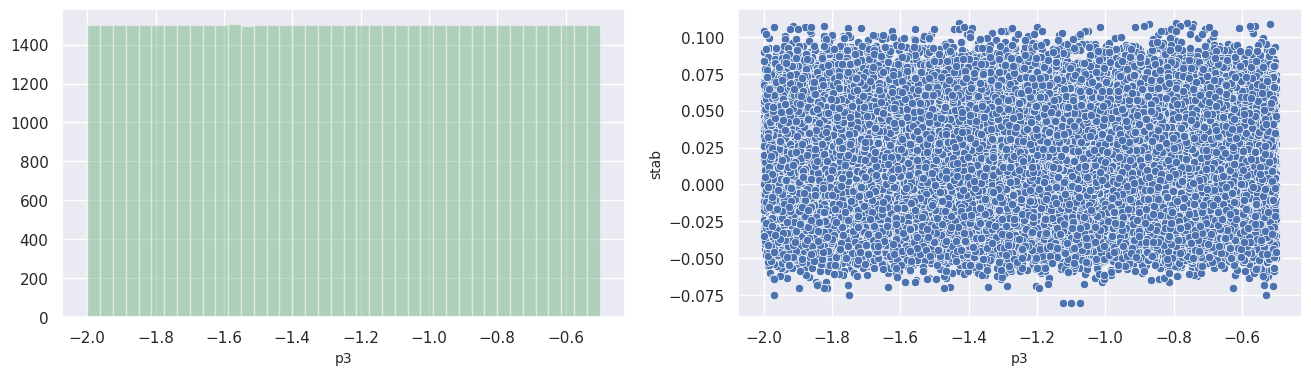

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


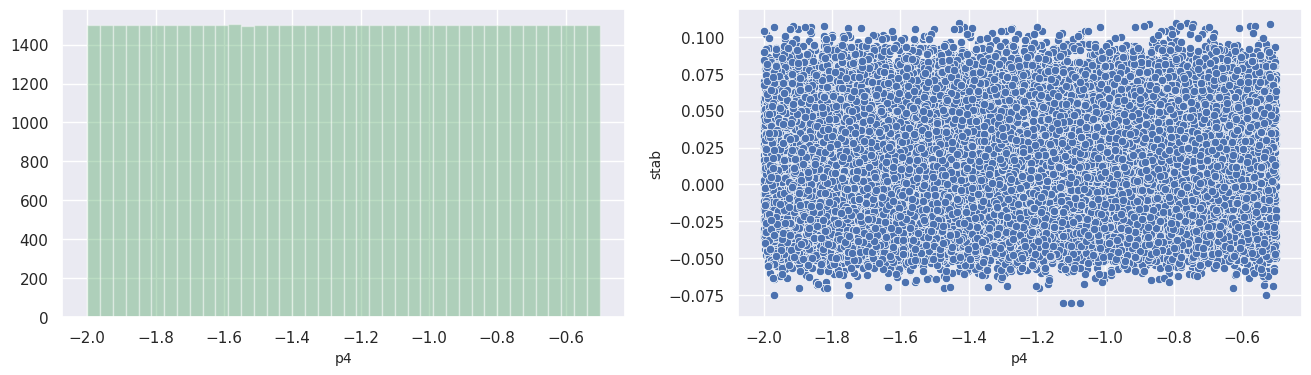

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


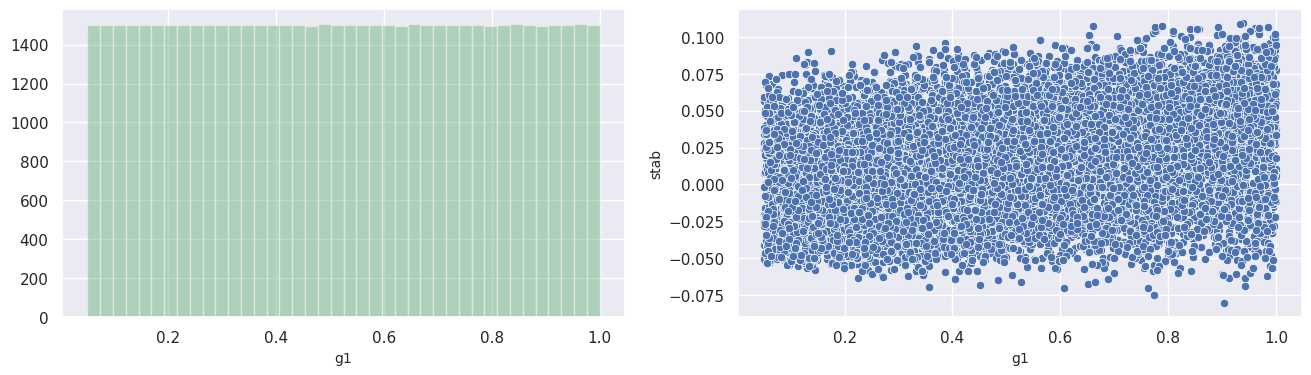

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


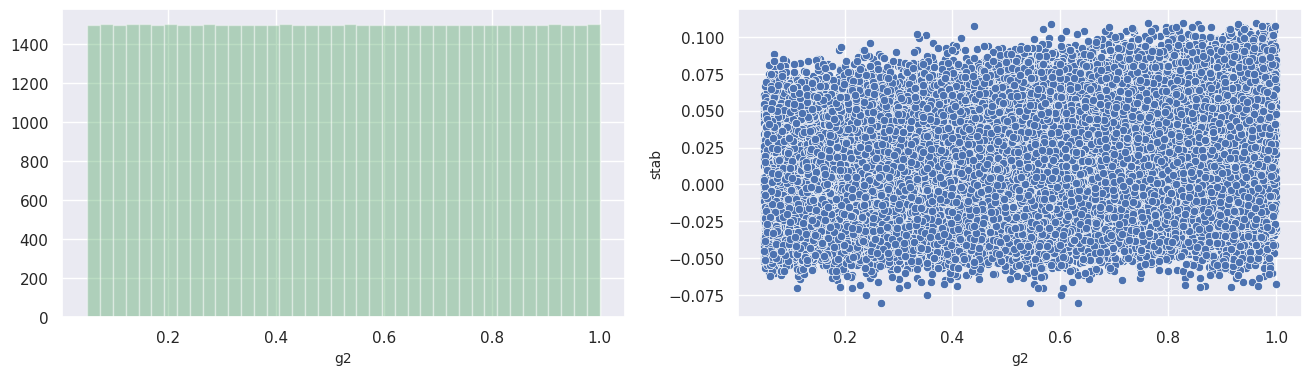

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


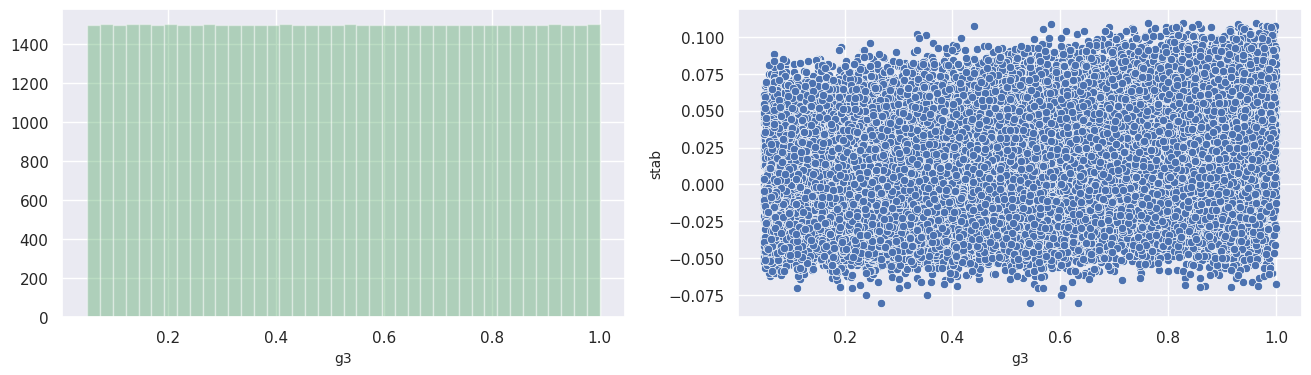

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


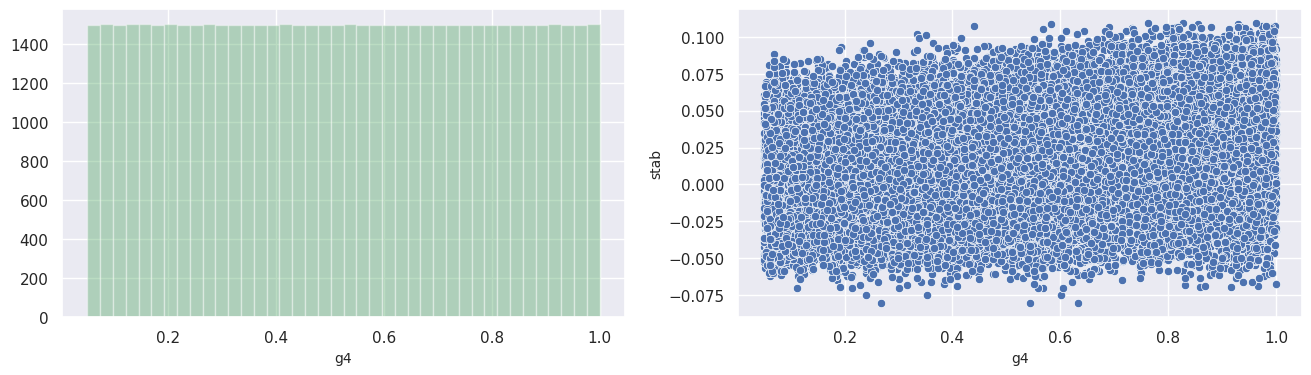

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


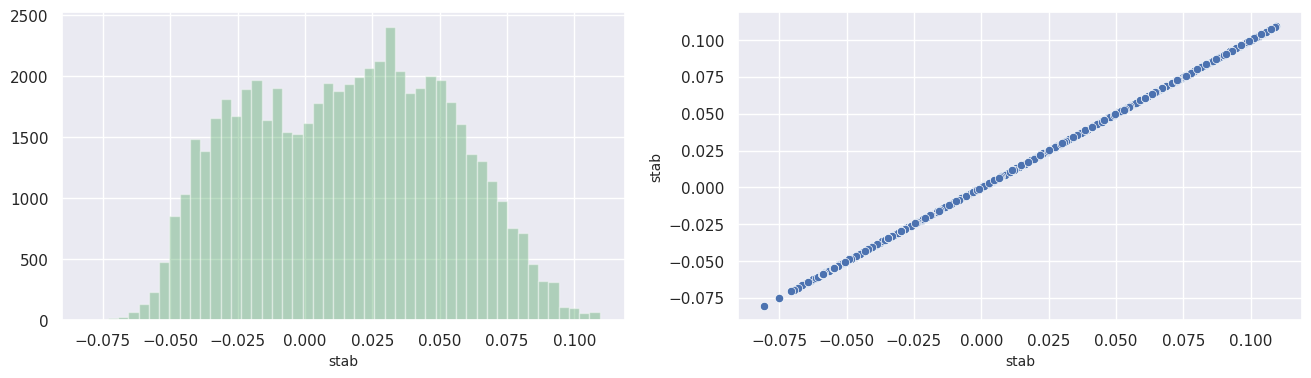

<ipython-input-2-da0488284cb4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  f_chart1 = sns.distplot(f_data[f_x_feature], ax=f_a[0], kde=False, color='g')


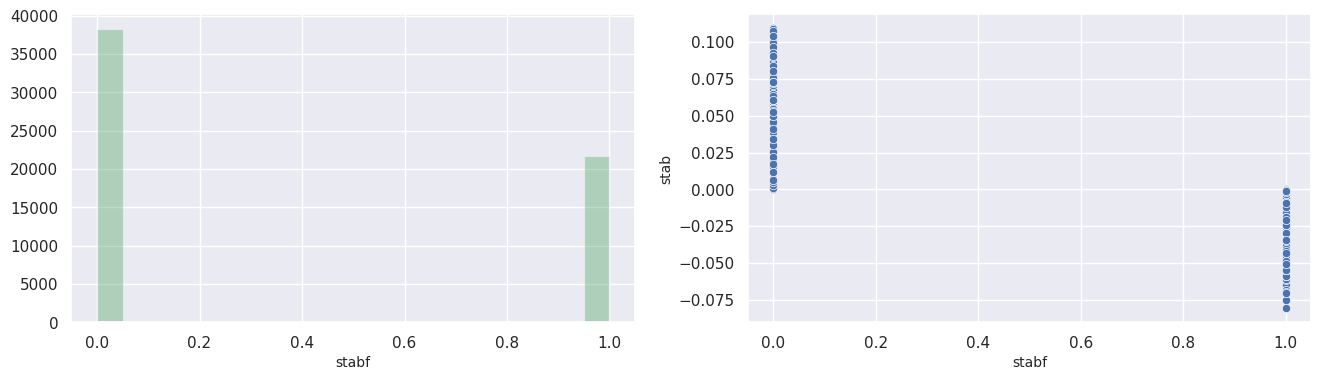

In [6]:
for column in data.columns:
    assessment(data, 'stab', column, -1)

In [7]:
data.p1.skew()

-0.012688423269881654

In [8]:
print(f'Split of "unstable" (0) and "stable" (1) observations in the original dataset:')
print(data['stabf'].value_counts(normalize=True))

Split of "unstable" (0) and "stable" (1) observations in the original dataset:
stabf
0    0.638
1    0.362
Name: proportion, dtype: float64


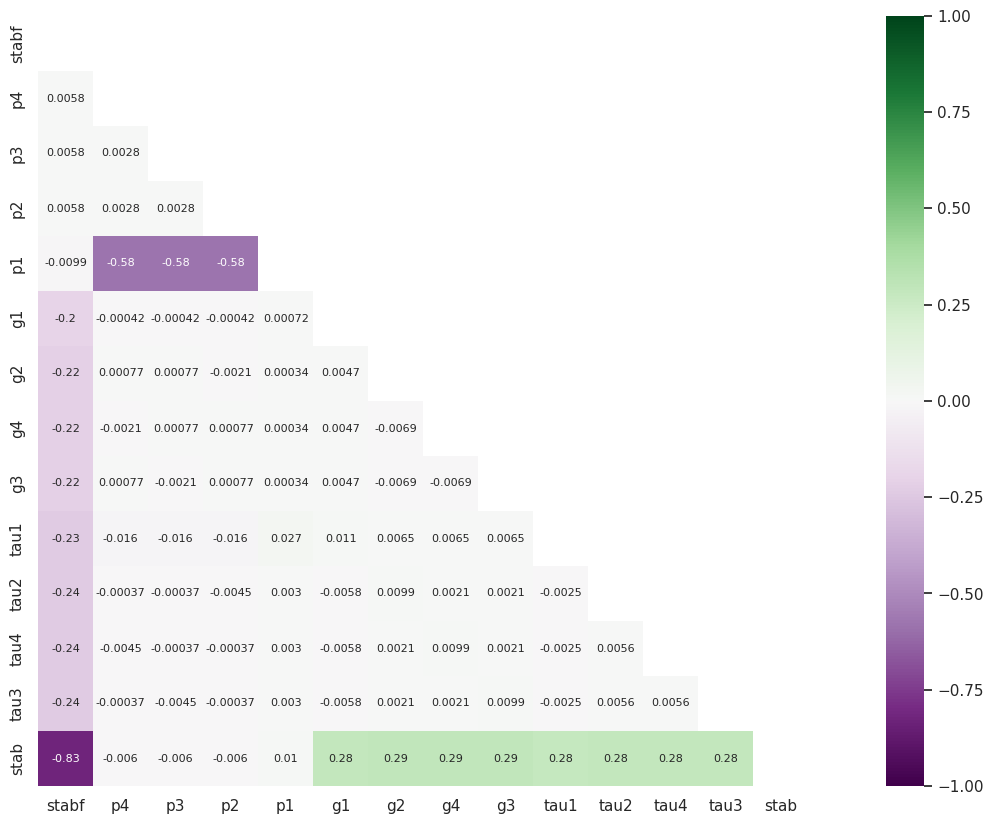

In [9]:
correlation_map(data, 'stabf', 14)

In [10]:
X = data.iloc[:, :12]
y = data.iloc[:, 13]

X_training = X.iloc[:54000, :]
y_training = y.iloc[:54000]

X_testing = X.iloc[54000:, :]
y_testing = y.iloc[54000:]

ratio_training = y_training.value_counts(normalize=True)
ratio_testing = y_testing.value_counts(normalize=True)
ratio_training, ratio_testing

(stabf
 0    0.636741
 1    0.363259
 Name: proportion, dtype: float64,
 stabf
 0    0.649333
 1    0.350667
 Name: proportion, dtype: float64)

In [11]:
scaler = StandardScaler()
X_training = scaler.fit_transform(X_training)
X_testing = scaler.transform(X_testing)

In [ ]:
# ANN initialization
classifier = Sequential()

# Input layer and first hidden layer
classifier.add(Dense(units=24, kernel_initializer='uniform', activation='relu', input_dim=12))

# Second hidden layer
classifier.add(Dense(units=24, kernel_initializer='uniform', activation='relu'))

# Third hidden layer
classifier.add(Dense(units=12, kernel_initializer='uniform', activation='relu'))

# Single-node output layer
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# ANN compilation
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cross_val_round = 1
print(f'Model evaluation\n')

In [ ]:
# Convert y_training to a NumPy array
y_training_np = y_training.to_numpy()

In [21]:
for train_index, val_index in KFold(10, shuffle=True, random_state=10).split(X_training):
    x_train, x_val = X_training[train_index], X_training[val_index]
    y_train, y_val = y_training_np[train_index], y_training_np[val_index]
    classifier.fit(x_train, y_train, epochs=50, verbose=0)
    classifier_loss, classifier_accuracy = classifier.evaluate(x_val, y_val)
    print(f'Round {cross_val_round} - Loss: {classifier_loss:.4f} | Accuracy: {classifier_accuracy * 100:.2f} %')
    cross_val_round += 1

Split of "unstable" (0) and "stable" (1) observations in the original dataset:
stabf
0    0.638
1    0.362
Name: proportion, dtype: float64
stabf
0    0.636741
1    0.363259
Name: proportion, dtype: float64 stabf
0    0.649333
1    0.350667
Name: proportion, dtype: float64


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model evaluation

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9713 - loss: 0.0754
Round 1 - Loss: 0.0731 | Accuracy: 97.07 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9763 - loss: 0.0584
Round 2 - Loss: 0.0609 | Accuracy: 97.57 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9792 - loss: 0.0528
Round 3 - Loss: 0.0614 | Accuracy: 97.50 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9808 - loss: 0.0509
Round 4 - Loss: 0.0507 | Accuracy: 98.09 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9793 - loss: 0.0578
Round 5 - Loss: 0.0559 | Accuracy: 97.83 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0478
Round 6 - Loss: 0.0456 | Accuracy: 98.24 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9877 - loss: 0.0302
Round 7 - Loss: 0.0340 | Accuracy: 98.54 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9857 - loss: 0.0342
Round 8 - Loss: 0.0366 | Accuracy: 98.50 %
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/st

In [22]:
y_pred = classifier.predict(X_testing)
y_pred[y_pred <= 0.5] = 0
y_pred[y_pred > 0.5] = 1

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [23]:
cm = pd.DataFrame(data=confusion_matrix(y_testing, y_pred, labels=[0, 1]),
                  index=["Actual Unstable", "Actual Stable"],
                  columns=["Predicted Unstable", "Predicted Stable"])
cm

,Predicted Unstable,Predicted Stable
Actual Unstable,3820,76
Actual Stable,39,2065


In [24]:
print(f'Accuracy per the confusion matrix: {((cm.iloc[0, 0] + cm.iloc[1, 1]) / len(y_testing) * 100):.2f}%')

Accuracy per the confusion matrix: 98.08%
